In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [2]:
!pip install -q ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 98.5 MB/s eta 0:00:00


In [3]:
import os
import shutil
from pathlib import Path

import yaml
import cv2
import matplotlib.pyplot as plt

from roboflow import Roboflow
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
from roboflow import Roboflow
rf = Roboflow(api_key="sWE0XtyK8WMpemV1adJn")
project = rf.workspace("shafiks-workspace").project("fmp-combined-dataset")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to FMP-Combined-DataSet-1 in yolov11:: 100%|██████████| 3051/3051 [00:00<00:00, 5472.41it/s]


In [5]:
print(dataset.location)

/content/FMP-Combined-DataSet-1


In [6]:
!ls -R "{dataset.location}" | head -100

/content/FMP-Combined-DataSet-1:
data.yaml
README.dataset.txt
README.roboflow.txt
test
train
valid

/content/FMP-Combined-DataSet-1/test:
images
labels

/content/FMP-Combined-DataSet-1/test/images:
00083_jpg.rf.c8d575561257433e2c8652a969002e99.jpg
001046_jpg.rf.3d7e04a5f5204639e0c1fd8164ce373e.jpg
001115_jpg.rf.25bff39f9915cb63eef1f069d86b990f.jpg
001140_jpg.rf.a6c3208c7bef52d733c8eb1e3f0f6abb.jpg
001154_jpg.rf.0027fabf9adea418b85e560823a474b9.jpg
001158_jpg.rf.c82929c494199808b58d7649682f86ce.jpg
001159_jpg.rf.e151aa638a1f40111ece9f8d761e8e5b.jpg
001168_jpg.rf.8229a81e0459ce5d79c3df3b65bac31d.jpg
001201_jpg.rf.8683be453a96846f078c4bf3fabaf037.jpg
001211_jpg.rf.016345365a0928dc65baf061f9e6de4f.jpg
001215_jpg.rf.7be2e88bb981c10f97c48d9bc72f7538.jpg
001218_jpg.rf.57de3b3760473da8f0ef13f077ae6f85.jpg
001221_jpg.rf.abdeb9cd48f8767e9ab49912cfcf2be4.jpg
001222_jpg.rf.4a1360d52276107ede356385701b4b8e.jpg
001222_jpg.rf.c8601674dedf54d04d1b7e293d527183.jpg
001223_jpg.rf.cdd0dcb5e6755fbea11689f9

In [7]:
yaml_path = os.path.join(dataset.location, "data.yaml")

with open(yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

print(data_config)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 3, 'names': ['Crack', 'Spalling', 'wire'], 'roboflow': {'workspace': 'shafiks-workspace', 'project': 'fmp-combined-dataset', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/shafiks-workspace/fmp-combined-dataset/dataset/1'}}


In [8]:
print("Classes:", data_config.get("names"))
print("Number of classes:", data_config.get("nc"))

Classes: ['Crack', 'Spalling', 'wire']
Number of classes: 3


In [9]:
for split in ["train", "valid", "test"]:
    img_dir = os.path.join(dataset.location, split, "images")
    if os.path.exists(img_dir):
        print(split, len(os.listdir(img_dir)))

train 1066
valid 304
test 153


In [10]:
import random
from PIL import Image

train_img_dir = Path(dataset.location) / "train" / "images"
sample_images = random.sample(list(train_img_dir.glob("*")), min(5, len(list(train_img_dir.glob("*")))))

sample_images

[PosixPath('/content/FMP-Combined-DataSet-1/train/images/s_data_131_jpg.rf.2f700f9ec4e03fff41912b0510d158c5.jpg'),
 PosixPath('/content/FMP-Combined-DataSet-1/train/images/WIN_20241012_16_51_04_Pro_jpg.rf.06b02f0b99b1072e9be15e373ad447c2.jpg'),
 PosixPath('/content/FMP-Combined-DataSet-1/train/images/crack-1922-_jpg.rf.7a8a704005ca774513ccda46e42e39ff.jpg'),
 PosixPath('/content/FMP-Combined-DataSet-1/train/images/crack-2043-_jpg.rf.d5cc337d148f0aba5318b5723bbda075.jpg'),
 PosixPath('/content/FMP-Combined-DataSet-1/train/images/20241002_131804_mp4-0292_jpg.rf.52641e085eeb0afc08986d95f959511b.jpg')]

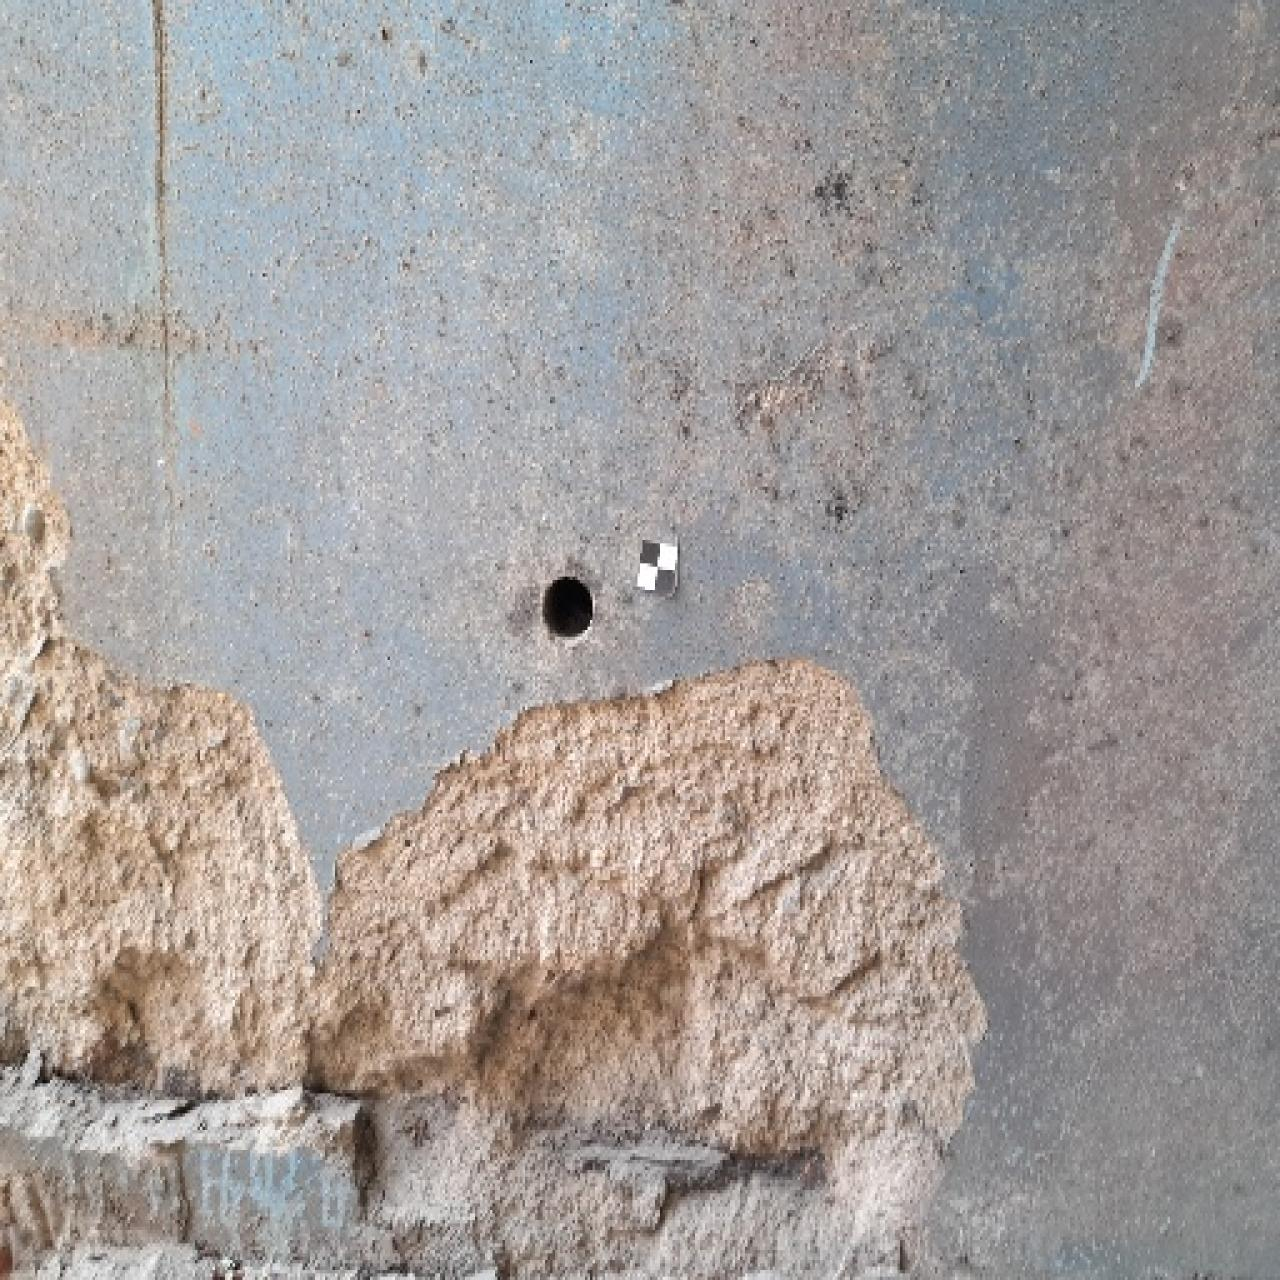

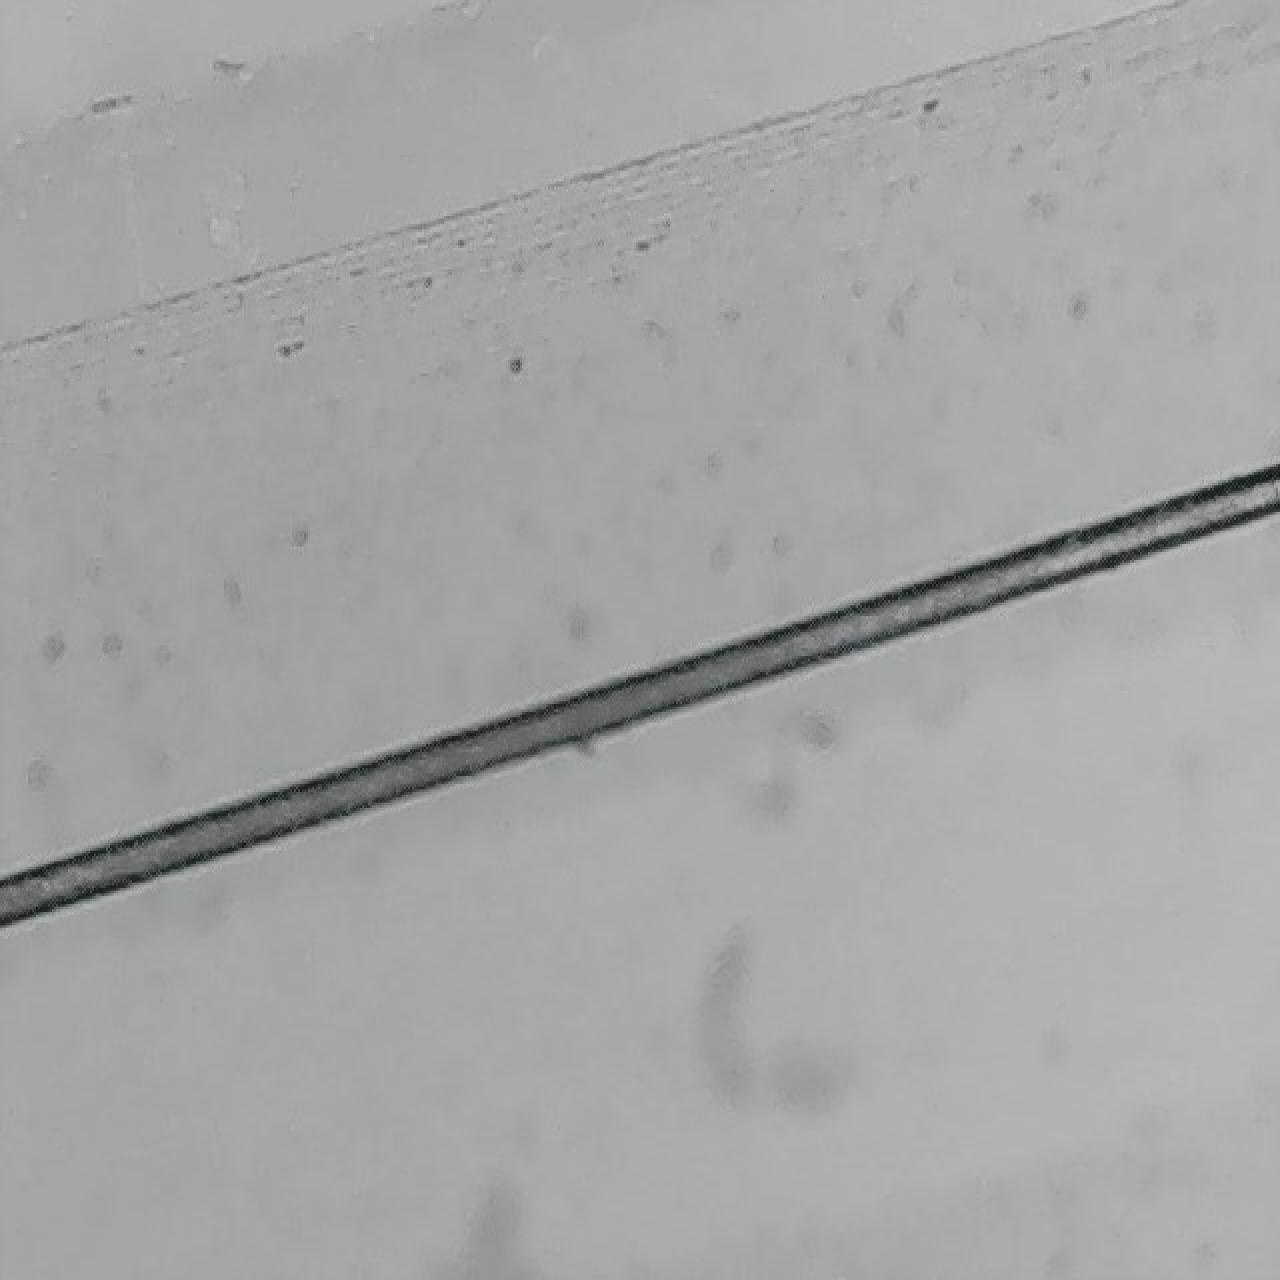

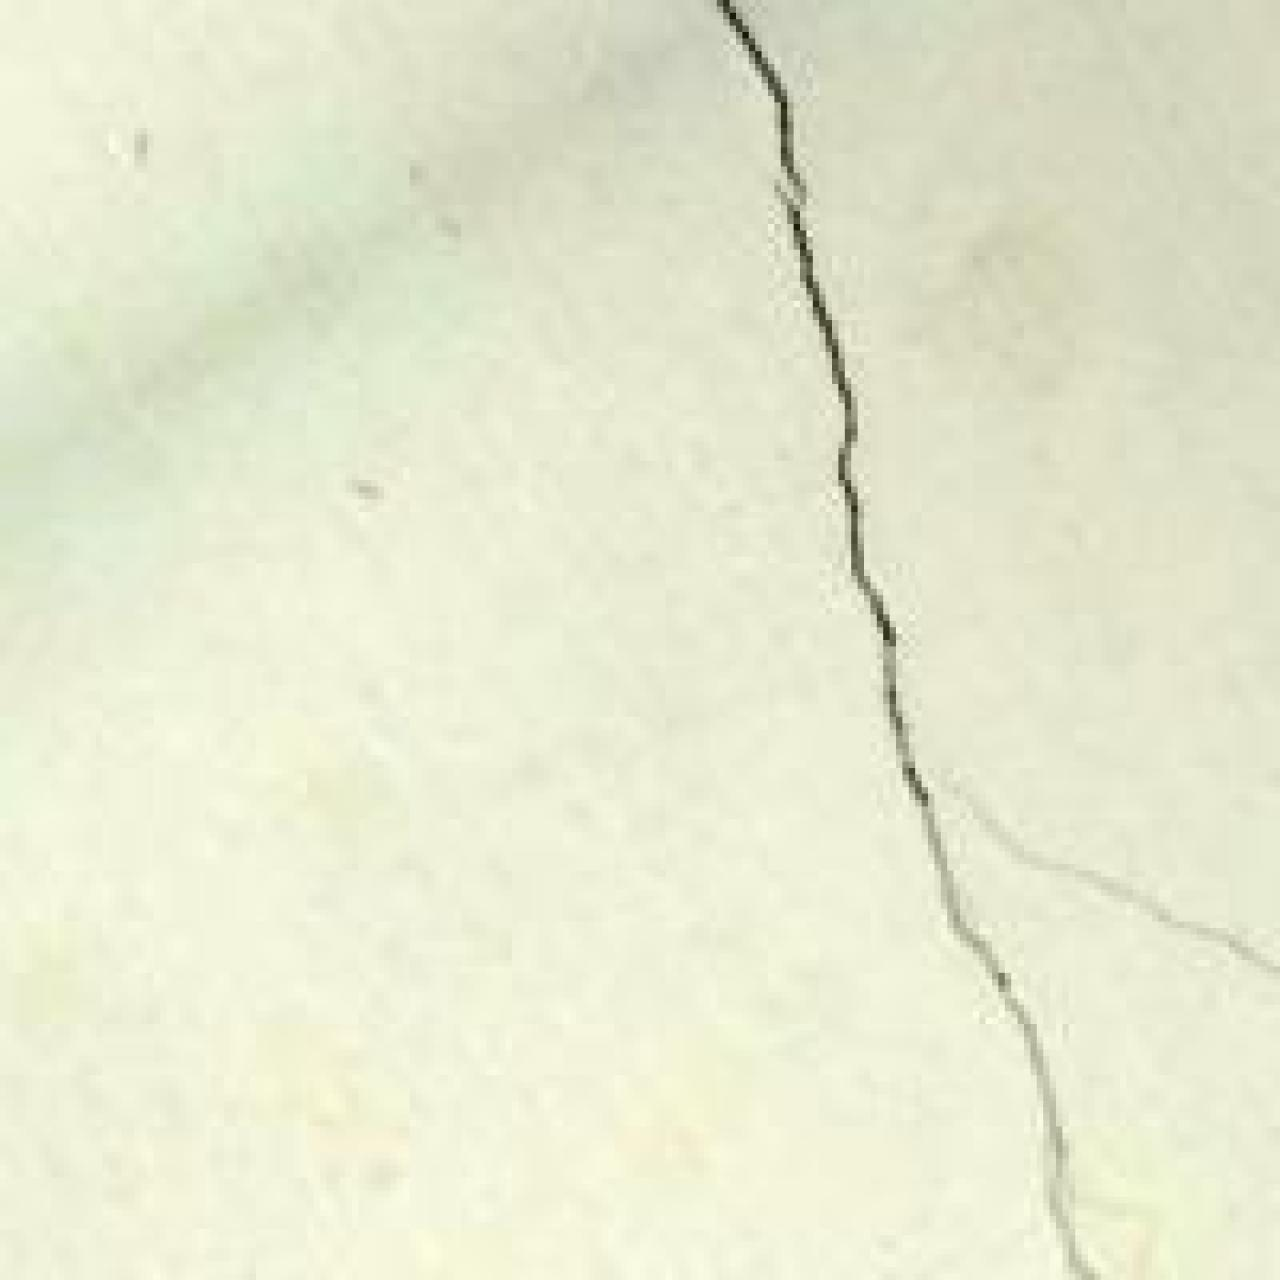

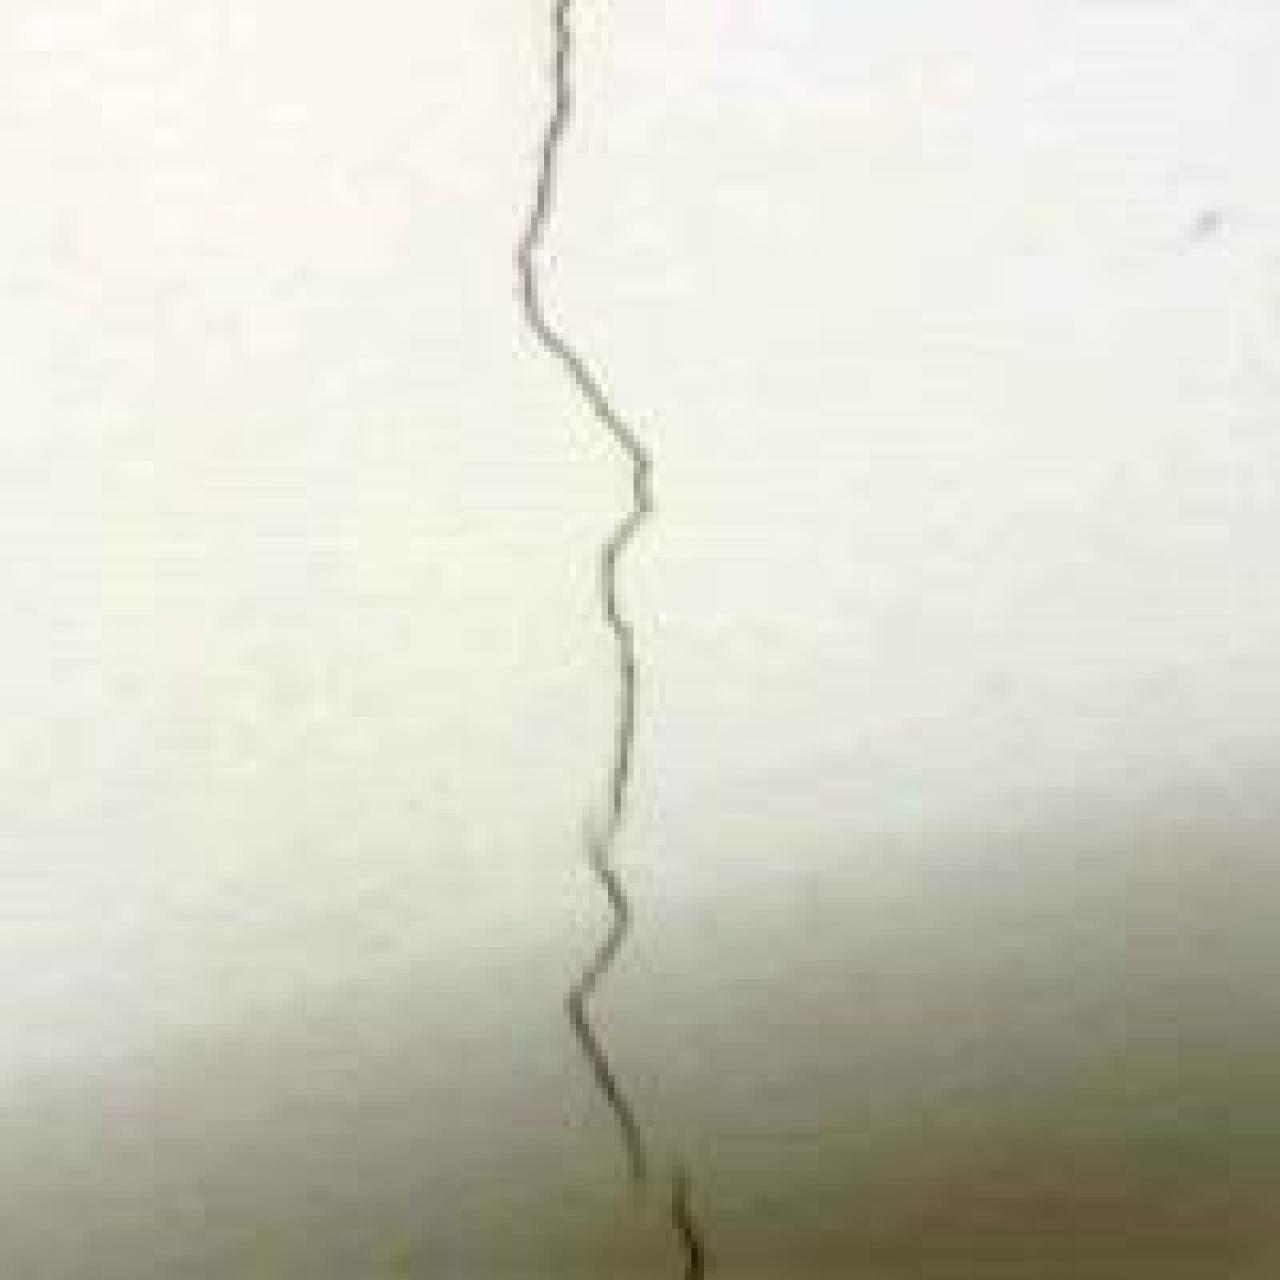

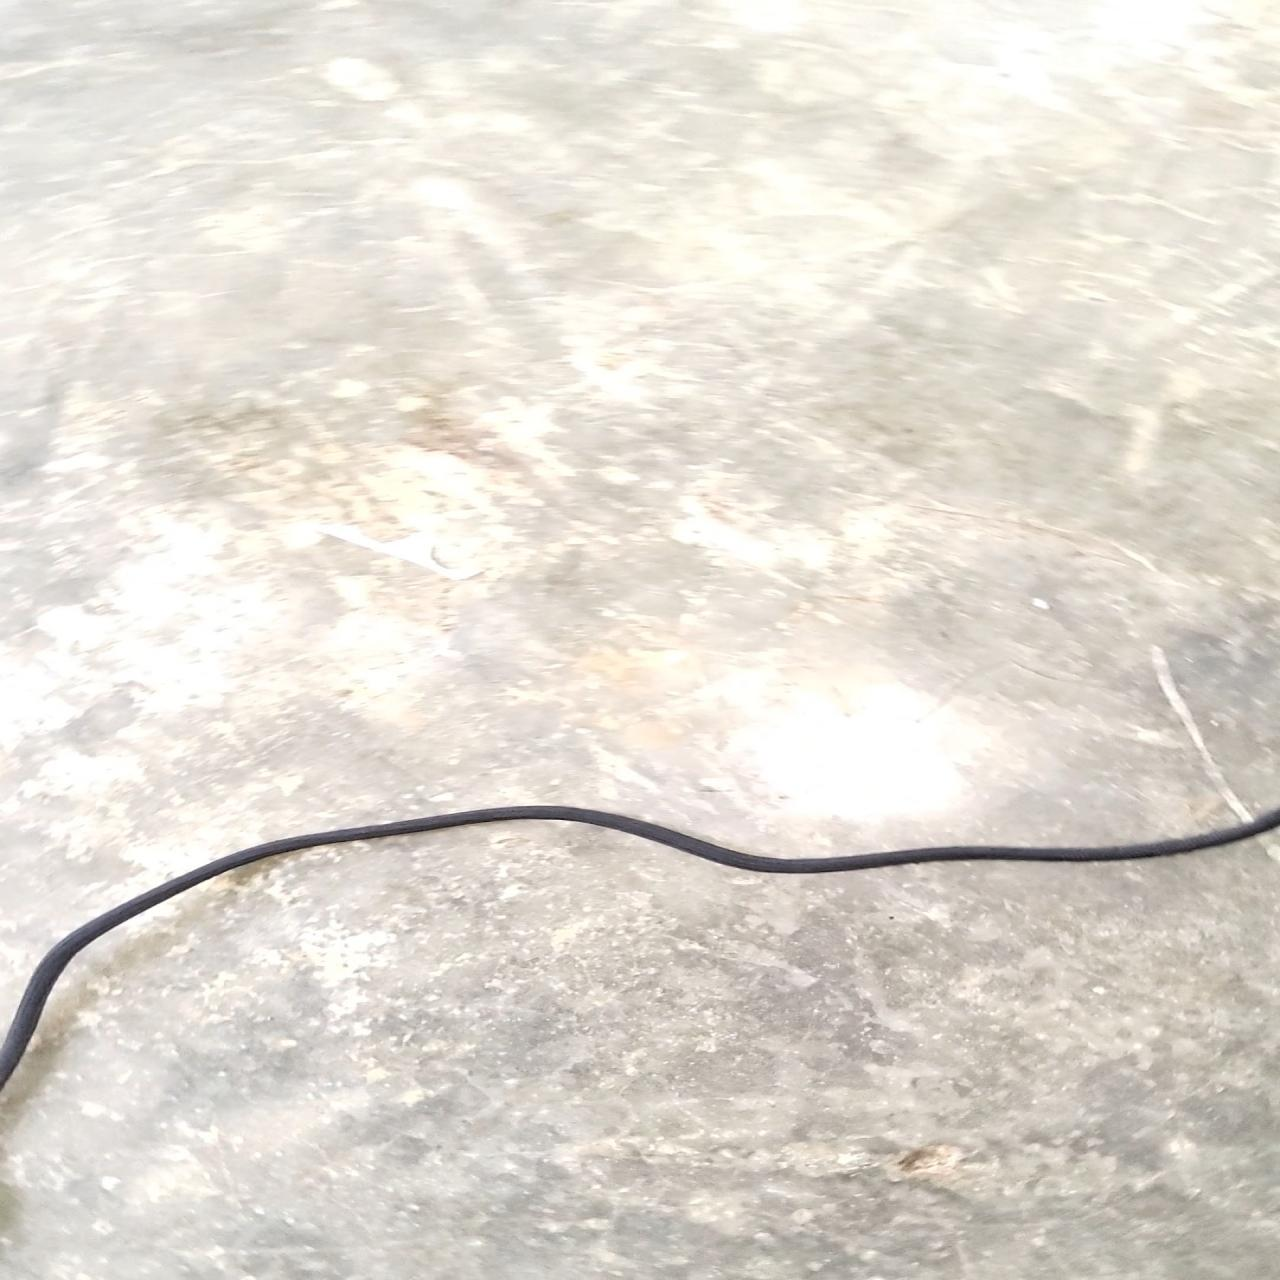

In [11]:
from IPython.display import display

for img_path in sample_images:
    display(Image.open(img_path))

In [12]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    DEVICE = 0
else:
    print("No GPU found. Training will use CPU.")
    DEVICE = "cpu"

CUDA available: True
GPU name: Tesla T4


In [13]:
model = YOLO("yolo11s.pt")

In [14]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    device=DEVICE,
    project="facade_yolo11",
    name="baseline_run",
    pretrained=True,
    patience=20,
    save=True,
    plots=True,
    workers=2,
    cache=True
)

Ultralytics 8.4.91 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FMP-Combined-DataSet-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

In [15]:
best_model = YOLO("runs/detect/facade_yolo11/baseline_run/weights/best.pt")

In [16]:
import os
import yaml

# Create a copy of the loaded data_config to modify
modified_data_config = data_config.copy()

# Set the base path for the dataset
modified_data_config['path'] = dataset.location

# Adjust the 'train', 'val', 'test' paths to be relative to the new 'path' key
# They are currently like '../train/images', but should be 'train/images'
for split_key in ["train", "val", "test"]:
    if split_key in modified_data_config:
        current_path_value = modified_data_config[split_key]
        if current_path_value.startswith('../'):
            # Remove the leading '../' if it exists, as it's now relative to 'path'
            modified_data_config[split_key] = current_path_value[3:]

# Define a new temporary yaml path for the modified config
temp_yaml_path = os.path.join(dataset.location, "modified_data.yaml")

# Write the modified data_config to the new YAML file
with open(temp_yaml_path, "w") as f:
    yaml.dump(modified_data_config, f, sort_keys=False) # sort_keys=False to preserve original order

# Now use this new yaml path for validation, with 'split="val"' to match the yaml key
val_metrics = best_model.val(data=temp_yaml_path, split="val", plots=True)
print(val_metrics)

Ultralytics 8.4.91 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2442.6±682.4 MB/s, size: 158.7 KB)
val: Scanning /content/FMP-Combined-DataSet-1/valid/labels.cache... 304 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 304/304 127.5Mit/s 0.0s
val: /content/FMP-Combined-DataSet-1/valid/images/crack-1311-_jpg.rf.51aad7cae0caf2b2715fa51dfe3fb499.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 3.6it/s 5.3s
                   all        304        470      0.916      0.828      0.882      0.781
                 Crack        101        159      0.888      0.742      0.826      0.684
              Spalling         87        174      0.891      0.751      0.826      0.705
                  wire        116        137      0.968      0.993      

In [17]:
test_metrics = best_model.val(data=yaml_path, split="test", plots=True)
print(test_metrics)

Ultralytics 8.4.91 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2223.5±969.1 MB/s, size: 81.5 KB)
val: Scanning /content/FMP-Combined-DataSet-1/test/labels... 153 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 153/153 1.0Kit/s 0.2s
val: /content/FMP-Combined-DataSet-1/test/images/CC007_jpg.rf.a55d7dfd9299da58b3749d5f7ca0c38b.jpg: 1 duplicate labels removed
val: New cache created: /content/FMP-Combined-DataSet-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.0it/s 3.3s
                   all        153        231      0.911      0.811       0.89      0.798
                 Crack         52         90      0.906      0.645      0.775      0.655
              Spalling         43         71      0.891      0.817      0.914      0.806
                  wire         57         70      0.936      0.971      0.982      0.934
Speed: 2.3

In [18]:
pred_results = best_model.predict(
    source=os.path.join(dataset.location, "test", "images"),
    conf=0.25,
    save=True,
    project="facade_yolo11",
    name="predictions_test"
)


image 1/153 /content/FMP-Combined-DataSet-1/test/images/00083_jpg.rf.c8d575561257433e2c8652a969002e99.jpg: 640x640 5 Cracks, 15.5ms
image 2/153 /content/FMP-Combined-DataSet-1/test/images/001046_jpg.rf.3d7e04a5f5204639e0c1fd8164ce373e.jpg: 640x640 1 Crack, 1 Spalling, 15.5ms
image 3/153 /content/FMP-Combined-DataSet-1/test/images/001115_jpg.rf.25bff39f9915cb63eef1f069d86b990f.jpg: 640x640 2 Spallings, 15.5ms
image 4/153 /content/FMP-Combined-DataSet-1/test/images/001140_jpg.rf.a6c3208c7bef52d733c8eb1e3f0f6abb.jpg: 640x640 1 Spalling, 15.5ms
image 5/153 /content/FMP-Combined-DataSet-1/test/images/001154_jpg.rf.0027fabf9adea418b85e560823a474b9.jpg: 640x640 6 Spallings, 15.5ms
image 6/153 /content/FMP-Combined-DataSet-1/test/images/001158_jpg.rf.c82929c494199808b58d7649682f86ce.jpg: 640x640 4 Spallings, 15.5ms
image 7/153 /content/FMP-Combined-DataSet-1/test/images/001159_jpg.rf.e151aa638a1f40111ece9f8d761e8e5b.jpg: 640x640 1 Spalling, 15.5ms
image 8/153 /content/FMP-Combined-DataSet-1/t

In [19]:
!ls facade_yolo11/baseline_run

ls: cannot access 'facade_yolo11/baseline_run': No such file or directory


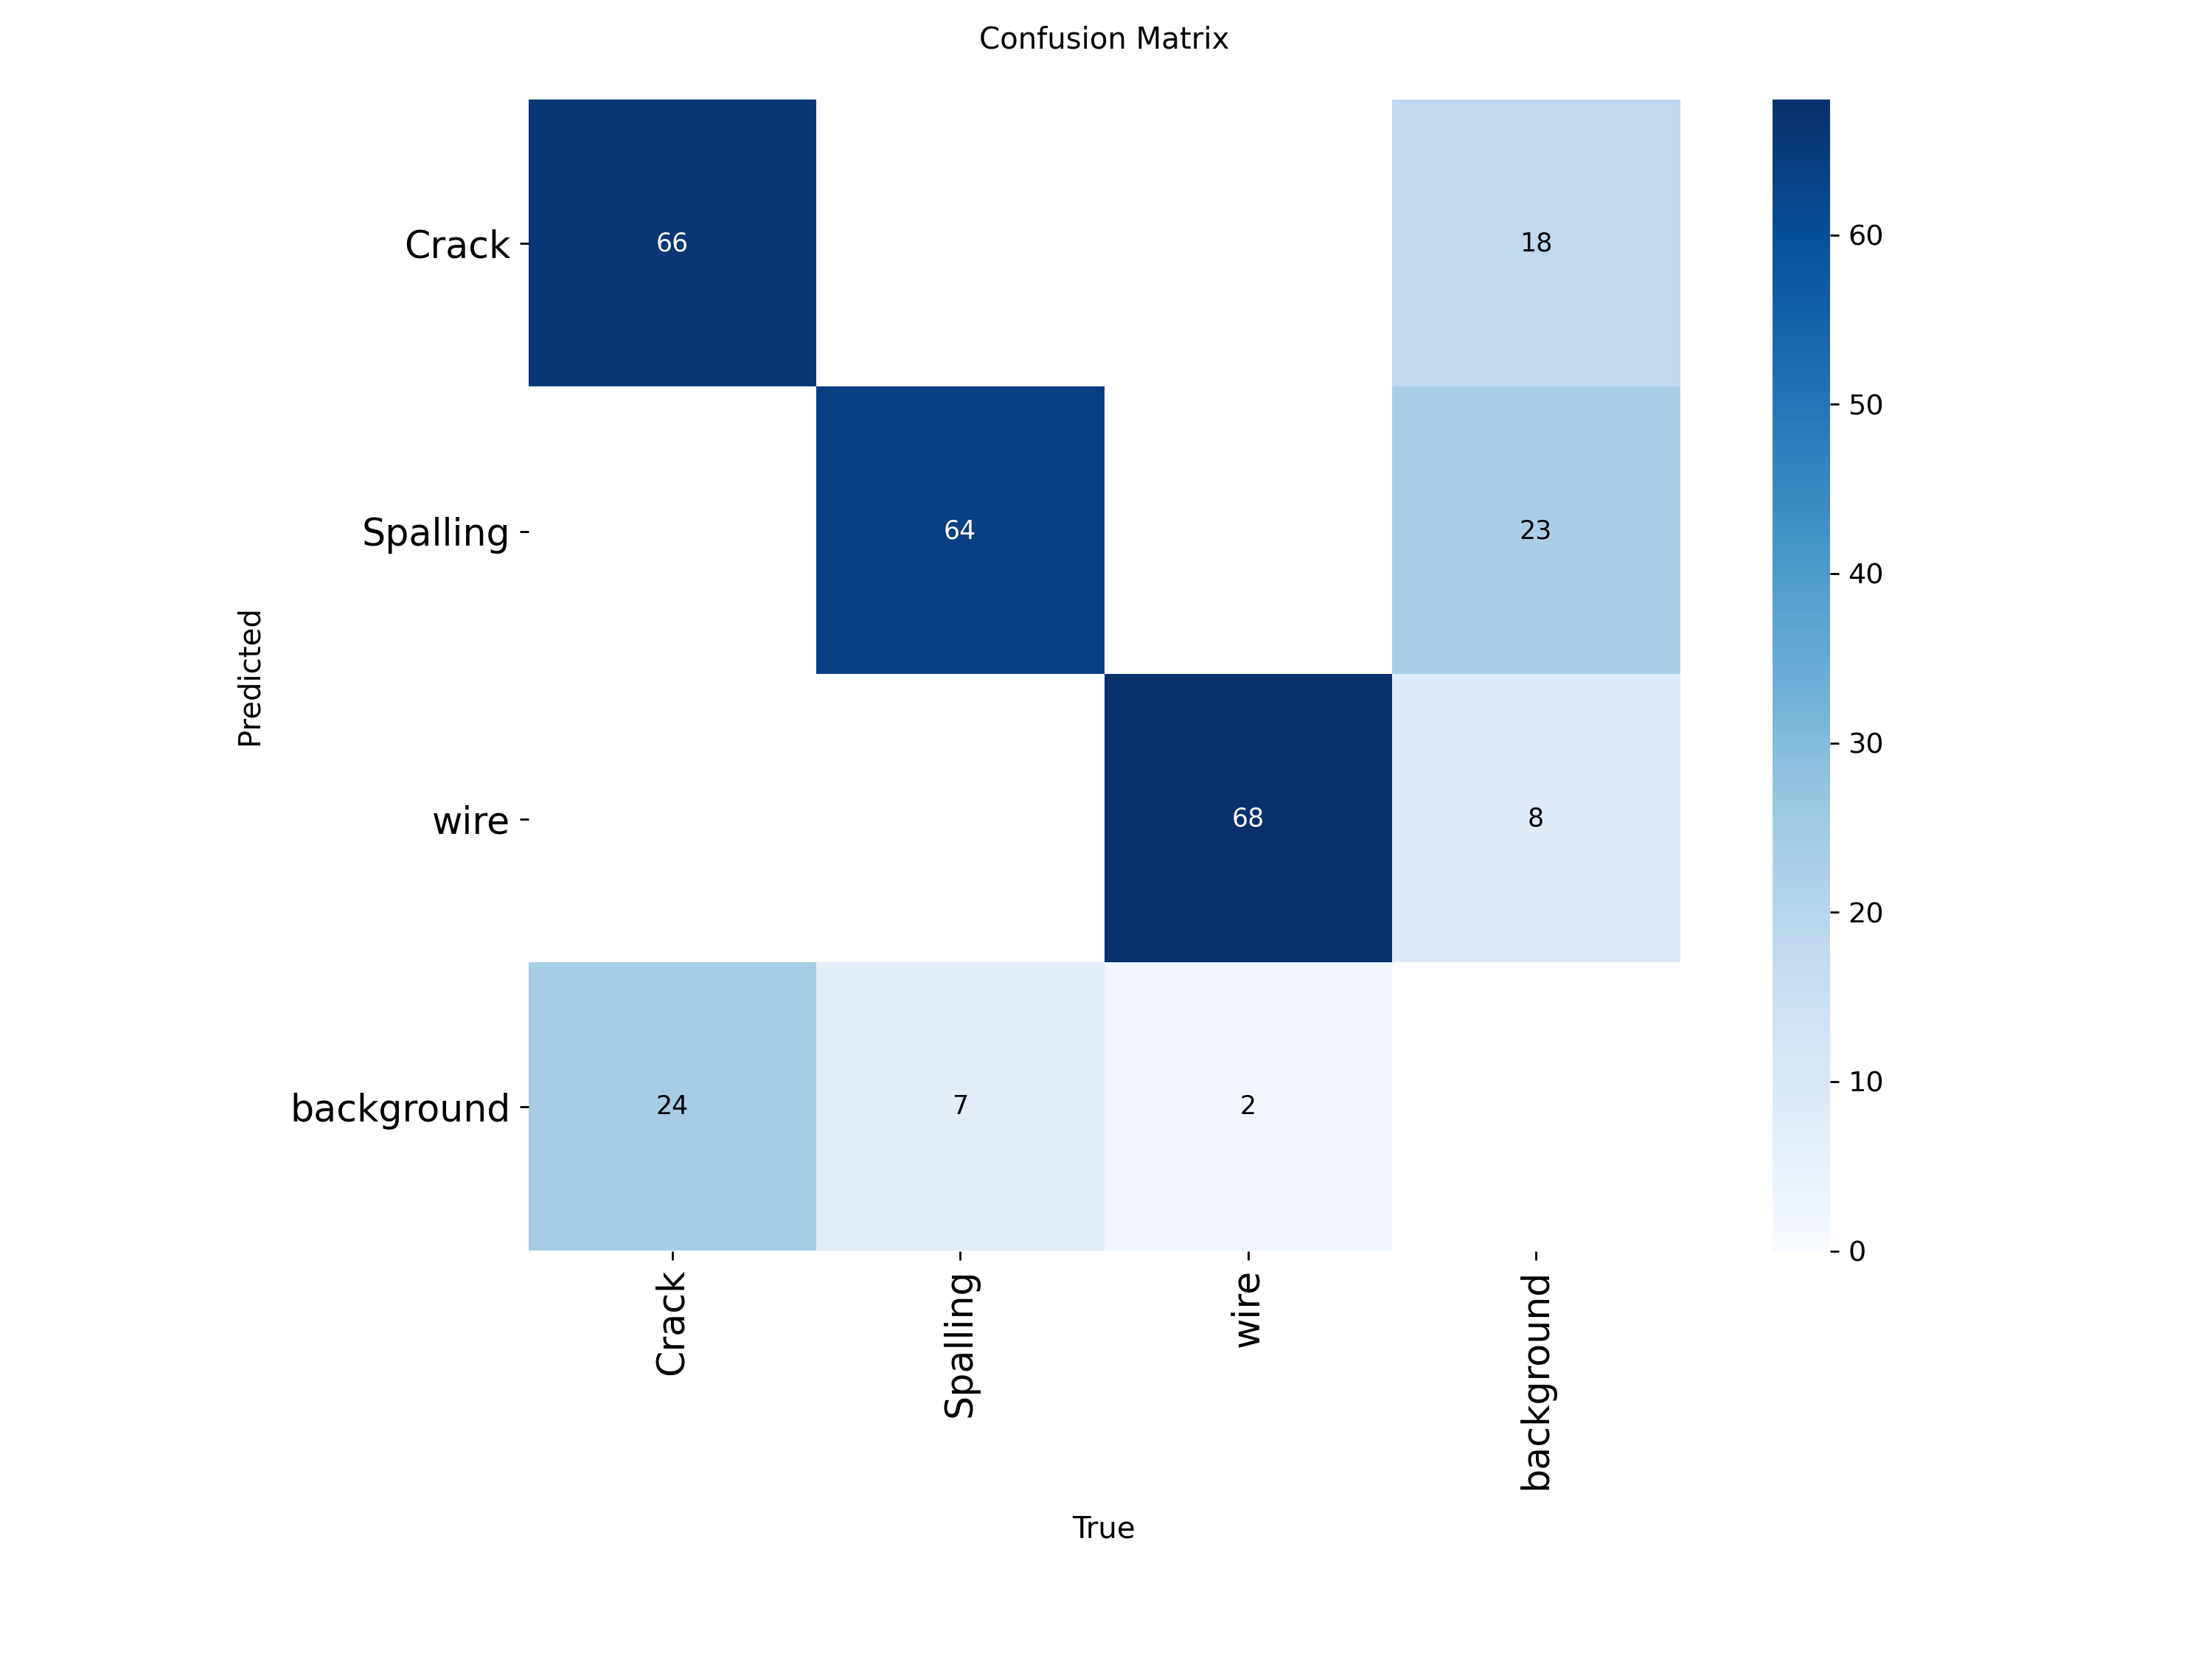

In [23]:
from IPython.display import Image
Image(filename='/content/runs/detect/val-2/confusion_matrix.png')

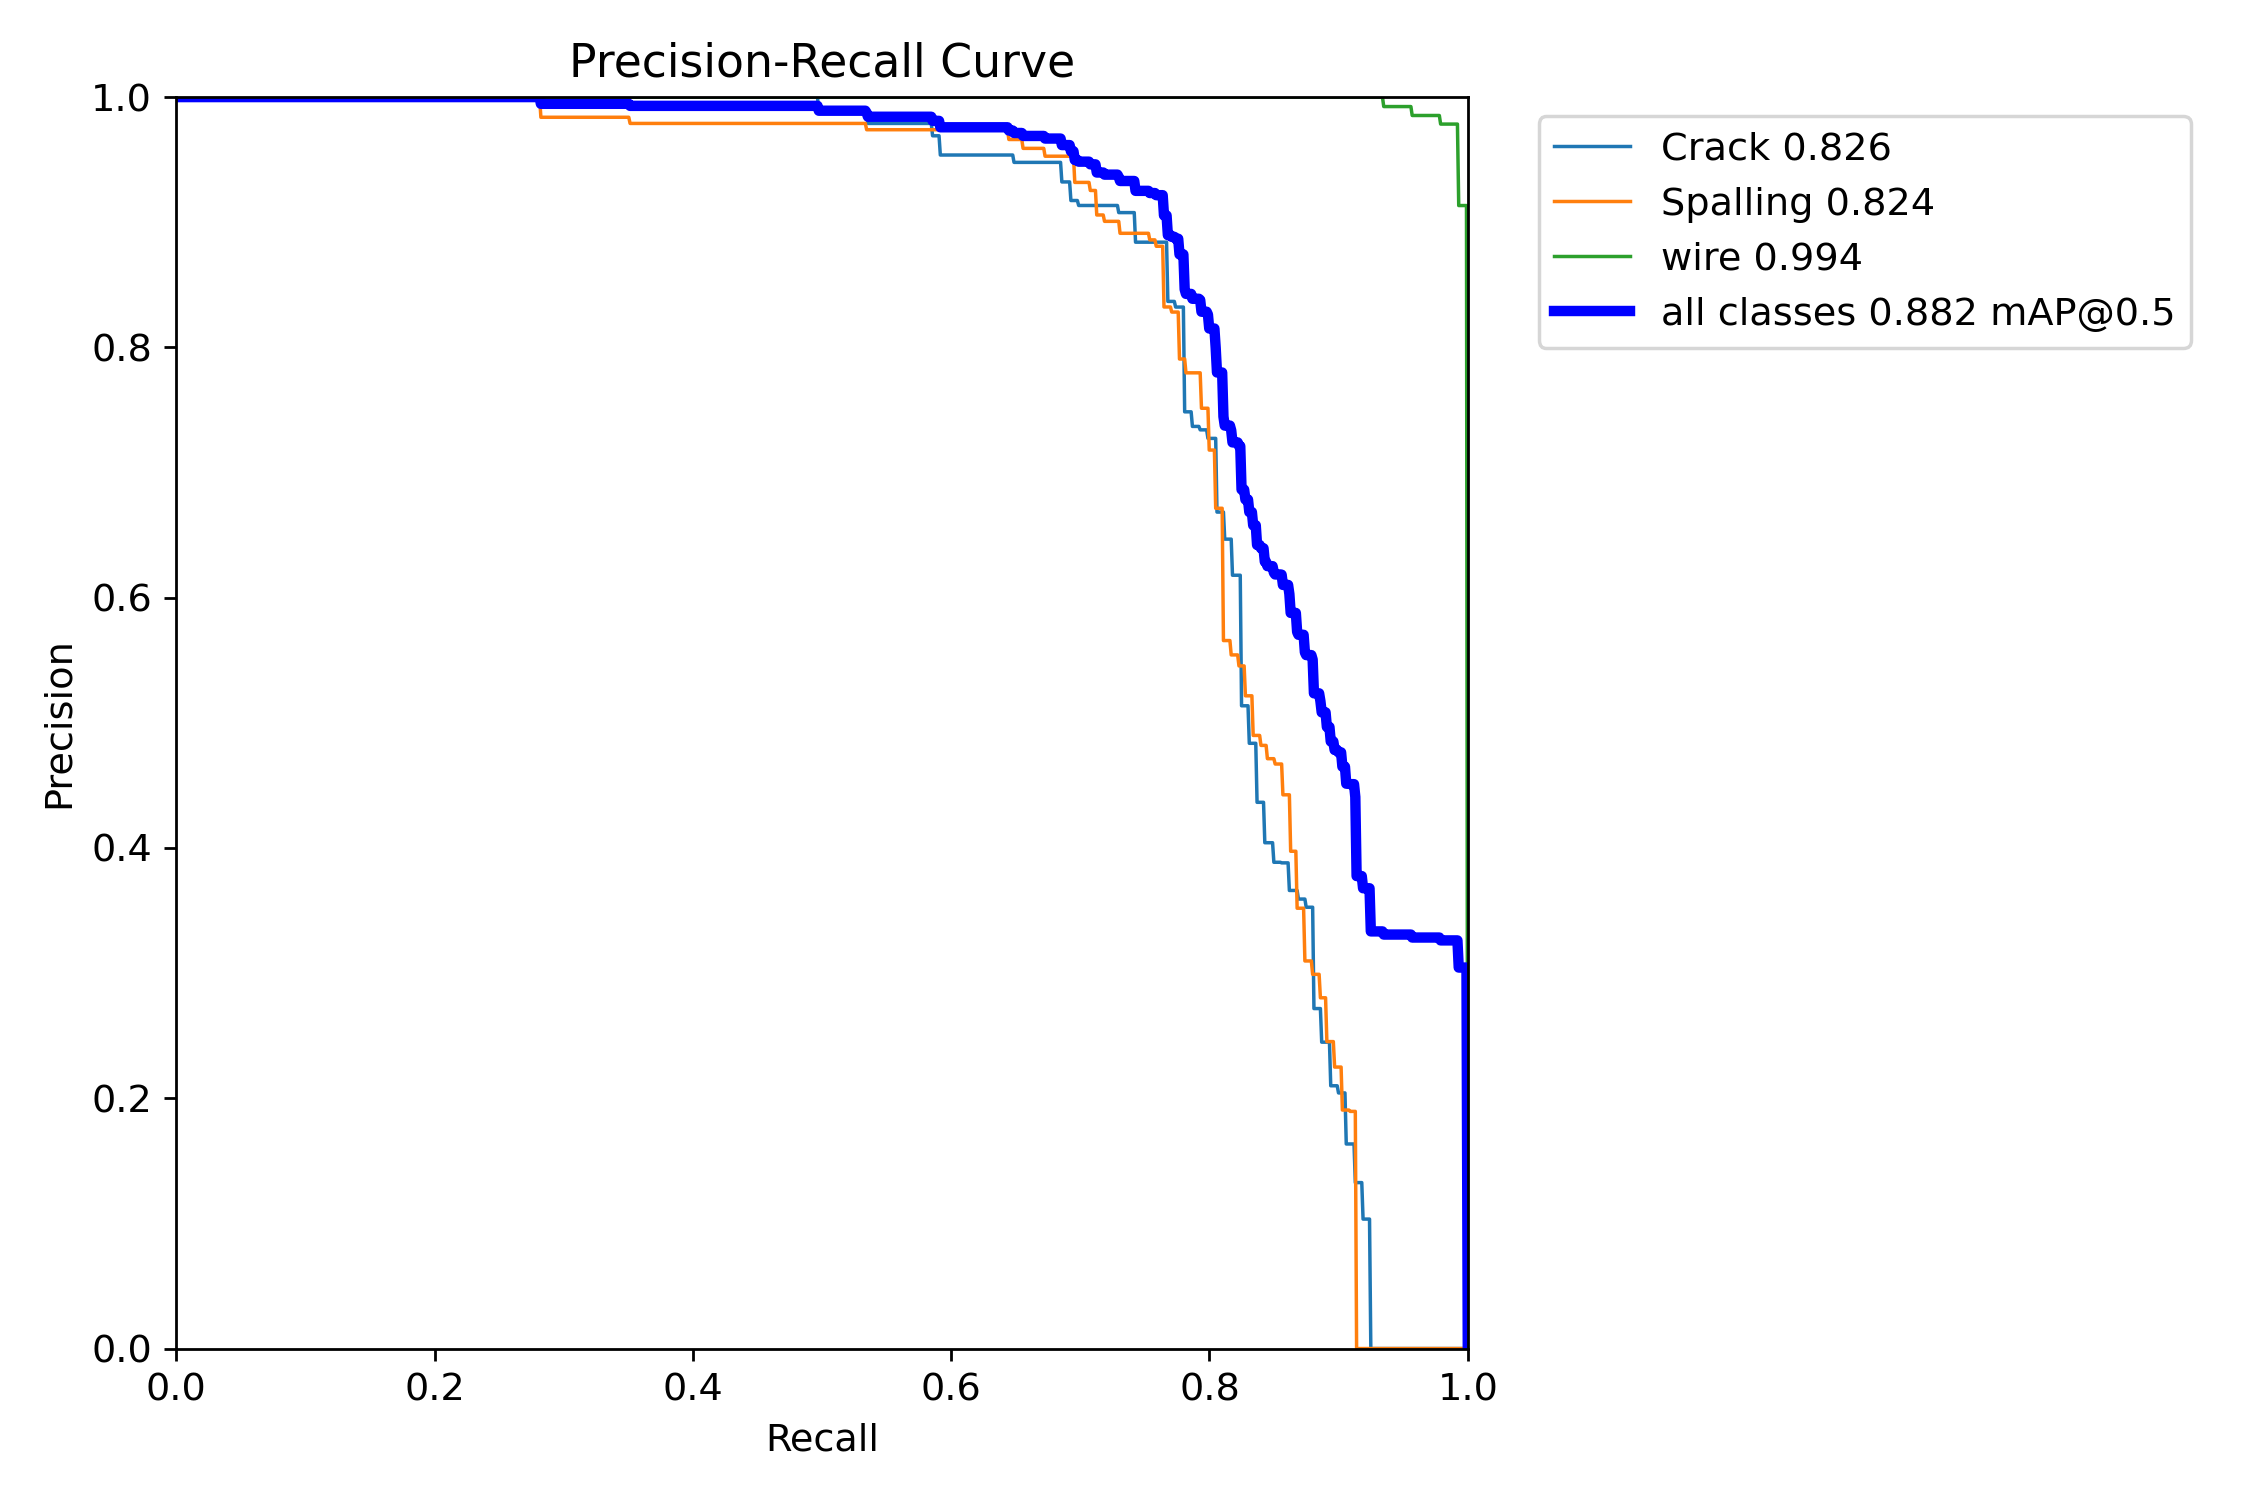

In [21]:
from IPython.display import Image
Image(filename="/content/runs/detect/facade_yolo11/baseline_run/BoxPR_curve.png")